# 02 — Feature Engineering & EDA

- Загрузка OHLCV из `data/raw/{TICKER}_ohlcv.parquet`
- Технические признаки (RSI, MACD, Bollinger, ATR, OBV, EMA, volume ratio)
- Lag-признаки (returns/volatility/rsi со сдвигом)
- Анализ распределений, корреляций, целевой переменной
- Сохранение в `data/processed/{TICKER}/technical.parquet`

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'backend'))

RAW_DIR = ROOT / 'data' / 'raw'
PROCESSED_DIR = ROOT / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use('dark_background')
sns.set_palette('husl')

TICKERS = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA",
    "ORCL", "CRM", "ADBE", "AMD", "INTC", "QCOM", "TXN",
    "JPM", "BAC", "GS", "MS", "WFC", "BLK", "AXP",
    "JNJ", "UNH", "PFE", "ABT", "MRK", "TMO",
    "WMT", "HD", "MCD", "KO", "PG", "COST", "NKE",
    "XOM", "CVX", "CAT", "BA", "HON",
    "T", "VZ", "DIS", "V", "MA",
]

print(f'Root:      {ROOT}')
print(f'Raw:       {RAW_DIR}')
print(f'Processed: {PROCESSED_DIR}')
print(f'Тикеров:   {len(TICKERS)}')

Root:      /Users/dvank1mang1/EquiSense
Raw:       /Users/dvank1mang1/EquiSense/data/raw
Processed: /Users/dvank1mang1/EquiSense/data/processed
Тикеров:   44


## 1. Загрузка сырых данных

In [2]:
from app.features.technical import TechnicalFeatureEngineer
from app.features.constants import TECHNICAL_FEATURES, LAG_FEATURES


def load_ohlcv(ticker: str) -> pd.DataFrame:
    path = RAW_DIR / f'{ticker}_ohlcv.parquet'
    if not path.exists():
        print(f'[WARN] {ticker}: {path.name} not found')
        return pd.DataFrame()
    df = pd.read_parquet(path)
    if 'date' not in df.columns:
        df = df.reset_index()
        df = df.rename(columns={df.columns[0]: 'date'})
    df['date'] = pd.to_datetime(df['date']).dt.tz_localize(None)
    df.columns = df.columns.str.lower()
    return df


raw_frames = {t: load_ohlcv(t) for t in TICKERS}
available = {t: df for t, df in raw_frames.items() if not df.empty}

print(f'Загружено: {list(available.keys())}')
for t, df in available.items():
    print(f'  {t}: {len(df)} строк  {df["date"].min().date()} – {df["date"].max().date()}')

Загружено: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', 'ORCL', 'CRM', 'ADBE', 'AMD', 'INTC', 'QCOM', 'TXN', 'JPM', 'BAC', 'GS', 'MS', 'WFC', 'BLK', 'AXP', 'JNJ', 'UNH', 'PFE', 'ABT', 'MRK', 'TMO', 'WMT', 'HD', 'MCD', 'KO', 'PG', 'COST', 'NKE', 'XOM', 'CVX', 'CAT', 'BA', 'HON', 'T', 'VZ', 'DIS', 'V', 'MA']
  AAPL: 1255 строк  2021-04-01 – 2026-03-31
  MSFT: 1255 строк  2021-04-01 – 2026-03-31
  GOOGL: 1255 строк  2021-04-01 – 2026-03-31
  AMZN: 1255 строк  2021-04-01 – 2026-03-31
  NVDA: 1255 строк  2021-04-01 – 2026-03-31
  META: 1255 строк  2021-04-01 – 2026-03-31
  TSLA: 1255 строк  2021-04-01 – 2026-03-31
  ORCL: 1255 строк  2021-04-01 – 2026-03-31
  CRM: 1255 строк  2021-04-01 – 2026-03-31
  ADBE: 1255 строк  2021-04-01 – 2026-03-31
  AMD: 1255 строк  2021-04-01 – 2026-03-31
  INTC: 1255 строк  2021-04-01 – 2026-03-31
  QCOM: 1255 строк  2021-04-01 – 2026-03-31
  TXN: 1255 строк  2021-04-01 – 2026-03-31
  JPM: 1255 строк  2021-04-01 – 2026-03-31
  BAC: 1255 строк  202

## 2. Вычисление признаков

In [3]:
engineer = TechnicalFeatureEngineer()
feature_frames = {}

for ticker, df in available.items():
    try:
        features = engineer.compute(df)
        features['ticker'] = ticker
        feature_frames[ticker] = features
        print(f'{ticker}: {len(features)} строк, {len(features.columns)} признаков')
    except Exception as e:
        print(f'[ERROR] {ticker}: {e}')

if not feature_frames:
    raise RuntimeError('Нет данных. Запустите ноутбук 01_data_collection.ipynb')

combined = pd.concat(feature_frames.values(), ignore_index=True)
print(f'\nВсего строк: {len(combined)}')
print(f'Колонки: {list(combined.columns)}')

AAPL: 1255 строк, 23 признаков
MSFT: 1255 строк, 23 признаков
GOOGL: 1255 строк, 23 признаков
AMZN: 1255 строк, 23 признаков
NVDA: 1255 строк, 23 признаков
META: 1255 строк, 23 признаков
TSLA: 1255 строк, 23 признаков
ORCL: 1255 строк, 23 признаков
CRM: 1255 строк, 23 признаков
ADBE: 1255 строк, 23 признаков
AMD: 1255 строк, 23 признаков
INTC: 1255 строк, 23 признаков
QCOM: 1255 строк, 23 признаков
TXN: 1255 строк, 23 признаков
JPM: 1255 строк, 23 признаков
BAC: 1255 строк, 23 признаков
GS: 1255 строк, 23 признаков
MS: 1255 строк, 23 признаков
WFC: 1255 строк, 23 признаков
BLK: 1255 строк, 23 признаков
AXP: 1255 строк, 23 признаков
JNJ: 1255 строк, 23 признаков
UNH: 1255 строк, 23 признаков
PFE: 1255 строк, 23 признаков
ABT: 1255 строк, 23 признаков
MRK: 1255 строк, 23 признаков
TMO: 1255 строк, 23 признаков
WMT: 1255 строк, 23 признаков
HD: 1255 строк, 23 признаков
MCD: 1255 строк, 23 признаков
KO: 1255 строк, 23 признаков
PG: 1255 строк, 23 признаков
COST: 1255 строк, 23 признаков
NK

## 3. Анализ пропусков

Признаки с пропусками:
                 count   pct
momentum           440  0.80
volatility_lag5    308  0.56
returns_lag5       264  0.48
rsi_lag3           258  0.47
returns_lag3       176  0.32
returns_lag2       132  0.24
rsi                126  0.23
volatility          88  0.16
returns_lag1        88  0.16
volume_lag1         88  0.16
returns             44  0.08
bb_upper            44  0.08
bb_lower            44  0.08
bb_width            44  0.08
volume_change       44  0.08


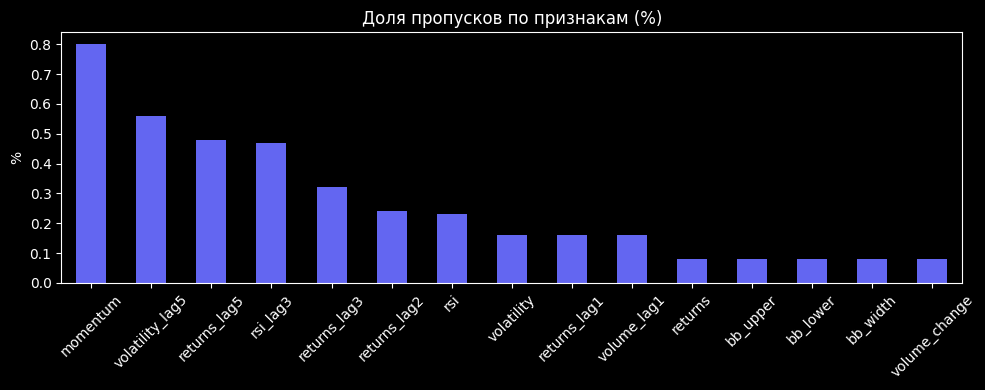

In [4]:
all_features = TECHNICAL_FEATURES + LAG_FEATURES

missing = combined[all_features].isnull().sum()
missing_pct = (missing / len(combined) * 100).round(2)
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct})
missing_df = missing_df[missing_df['count'] > 0].sort_values('pct', ascending=False)

if missing_df.empty:
    print('Пропусков нет!')
else:
    print('Признаки с пропусками:')
    print(missing_df.to_string())
    fig, ax = plt.subplots(figsize=(10, 4))
    missing_df['pct'].plot(kind='bar', ax=ax, color='#6366f1')
    ax.set_title('Доля пропусков по признакам (%)')
    ax.set_ylabel('%')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

## 4. Статистика и распределения технических признаков

In [5]:
stats = combined[all_features].describe().T
stats['skew'] = combined[all_features].skew()
stats['kurt'] = combined[all_features].kurt()
print(stats[['mean', 'std', 'min', 'max', 'skew', 'kurt']].round(4).to_string())

                     mean       std       min        max    skew     kurt
returns            0.0006    0.0197   -0.2639     0.3595  0.2310  13.4803
volatility         0.0175    0.0090    0.0006     0.0897  1.9336   5.8572
rsi               52.3041   17.5810    0.0000    99.1272  0.0048  -0.5483
macd               0.5847    5.6282  -48.9038    40.5386 -0.0205   8.1019
macd_signal        0.5995    5.2710  -43.6689    35.2352  0.0346   7.8117
macd_hist         -0.0148    1.7176  -19.1654    13.2829 -0.3185  10.5313
sma_20           214.4095  187.8213   12.2010  1149.0777  1.7719   3.6438
sma_50           213.1655  186.1938   12.6509  1127.8720  1.7628   3.6126
sma_200          207.1220  178.3232   13.7770  1074.0919  1.7137   3.3892
bb_upper         227.2011  198.2157   12.5754  1200.0601  1.7446   3.4881
bb_lower         201.6852  177.9763   10.8538  1111.0807  1.8077   3.8461
bb_width           0.1224    0.0777    0.0016     0.9151  2.2077   8.4902
momentum           0.7317   15.9777 -1

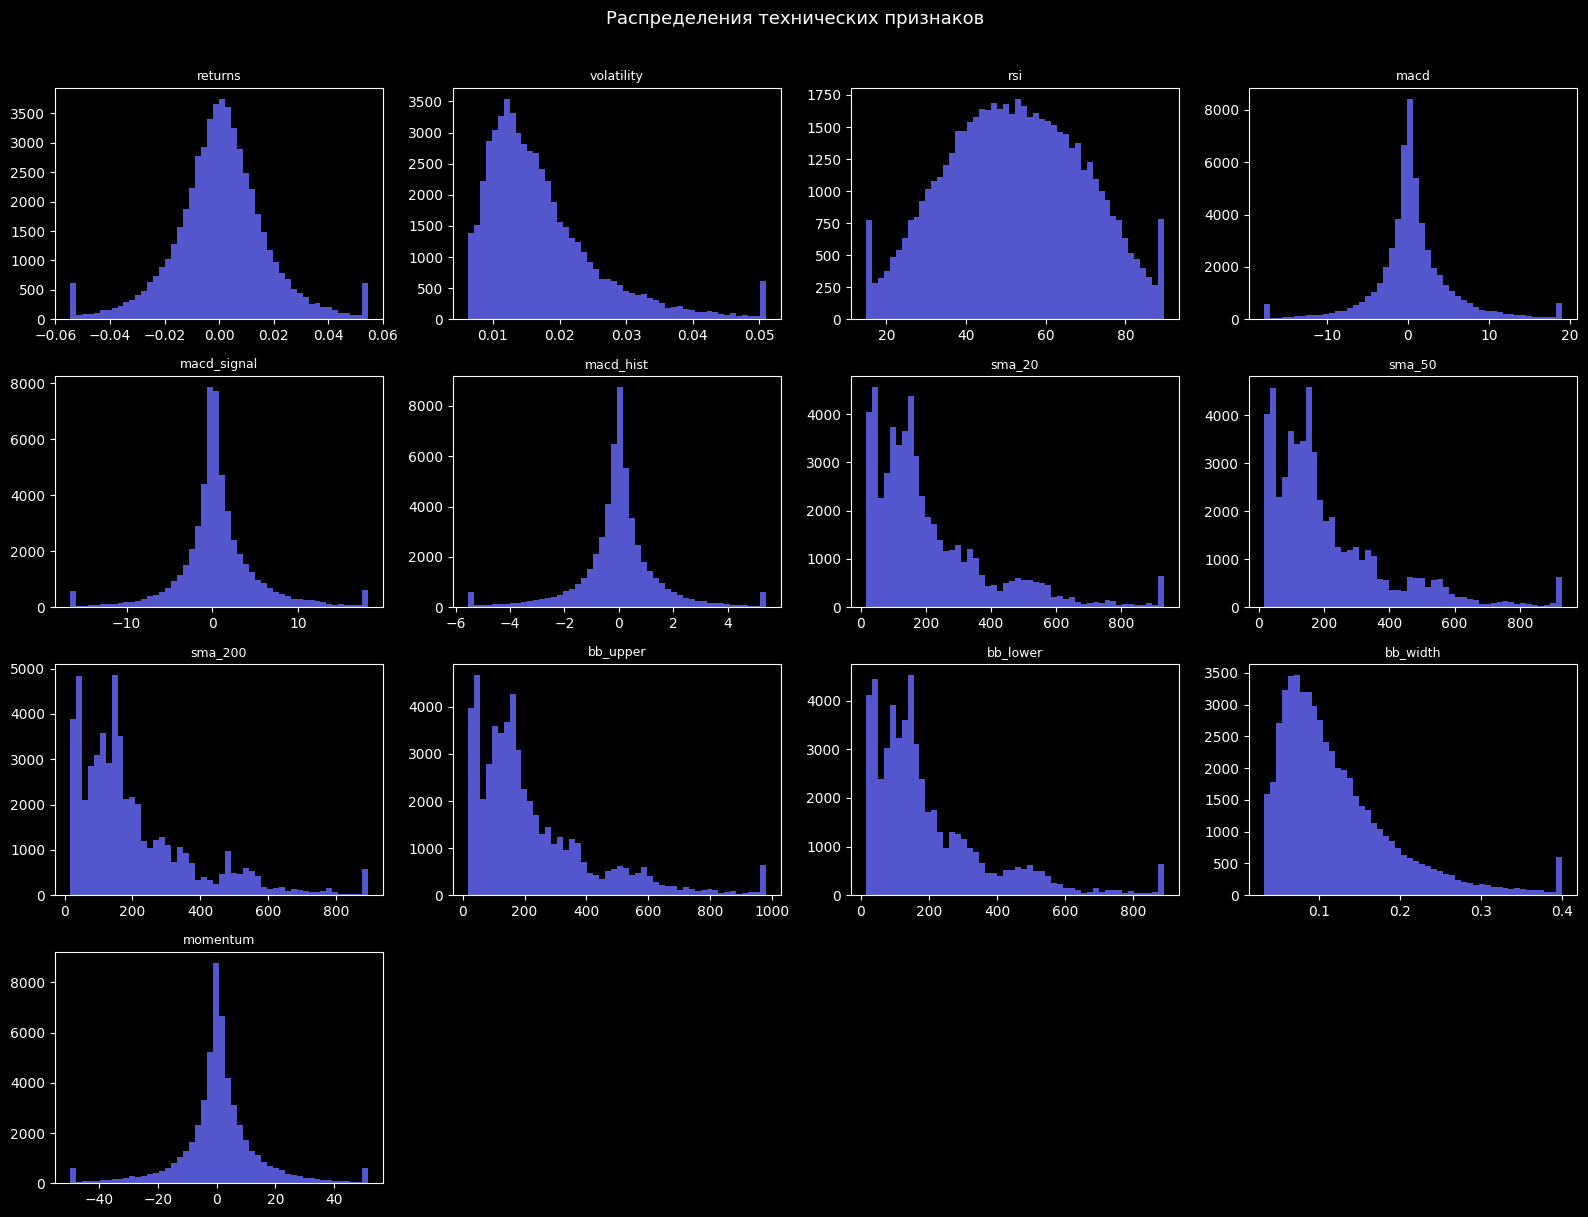

In [6]:
sample = combined[TECHNICAL_FEATURES].dropna()

n_cols = 4
n_rows = (len(TECHNICAL_FEATURES) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(TECHNICAL_FEATURES):
    data = sample[col].dropna()
    lo, hi = data.quantile(0.01), data.quantile(0.99)
    axes[i].hist(data.clip(lo, hi), bins=50, color='#6366f1', alpha=0.85)
    axes[i].set_title(col, fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Распределения технических признаков', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. Lag-признаки

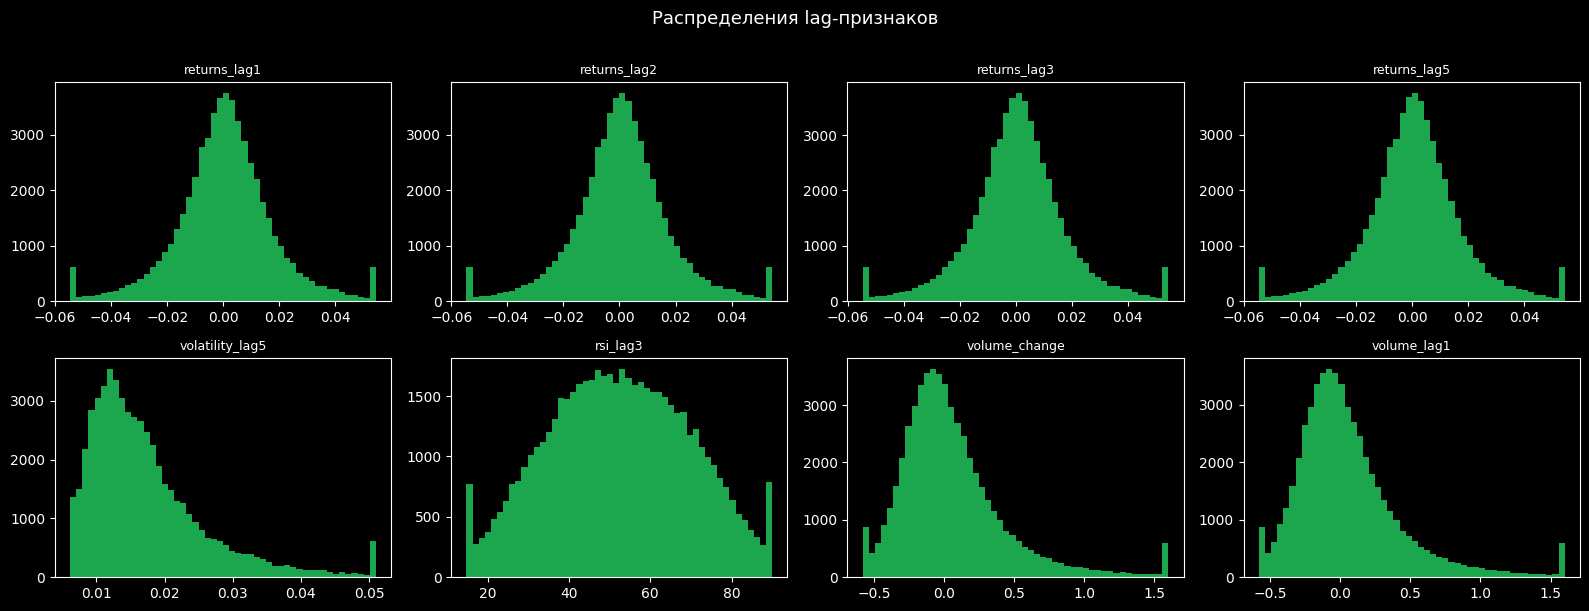

In [7]:
lag_sample = combined[LAG_FEATURES].dropna()

n_cols = 4
n_rows = (len(LAG_FEATURES) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(LAG_FEATURES):
    data = lag_sample[col].dropna()
    lo, hi = data.quantile(0.01), data.quantile(0.99)
    axes[i].hist(data.clip(lo, hi), bins=50, color='#22c55e', alpha=0.85)
    axes[i].set_title(col, fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Распределения lag-признаков', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 6. Корреляционная матрица

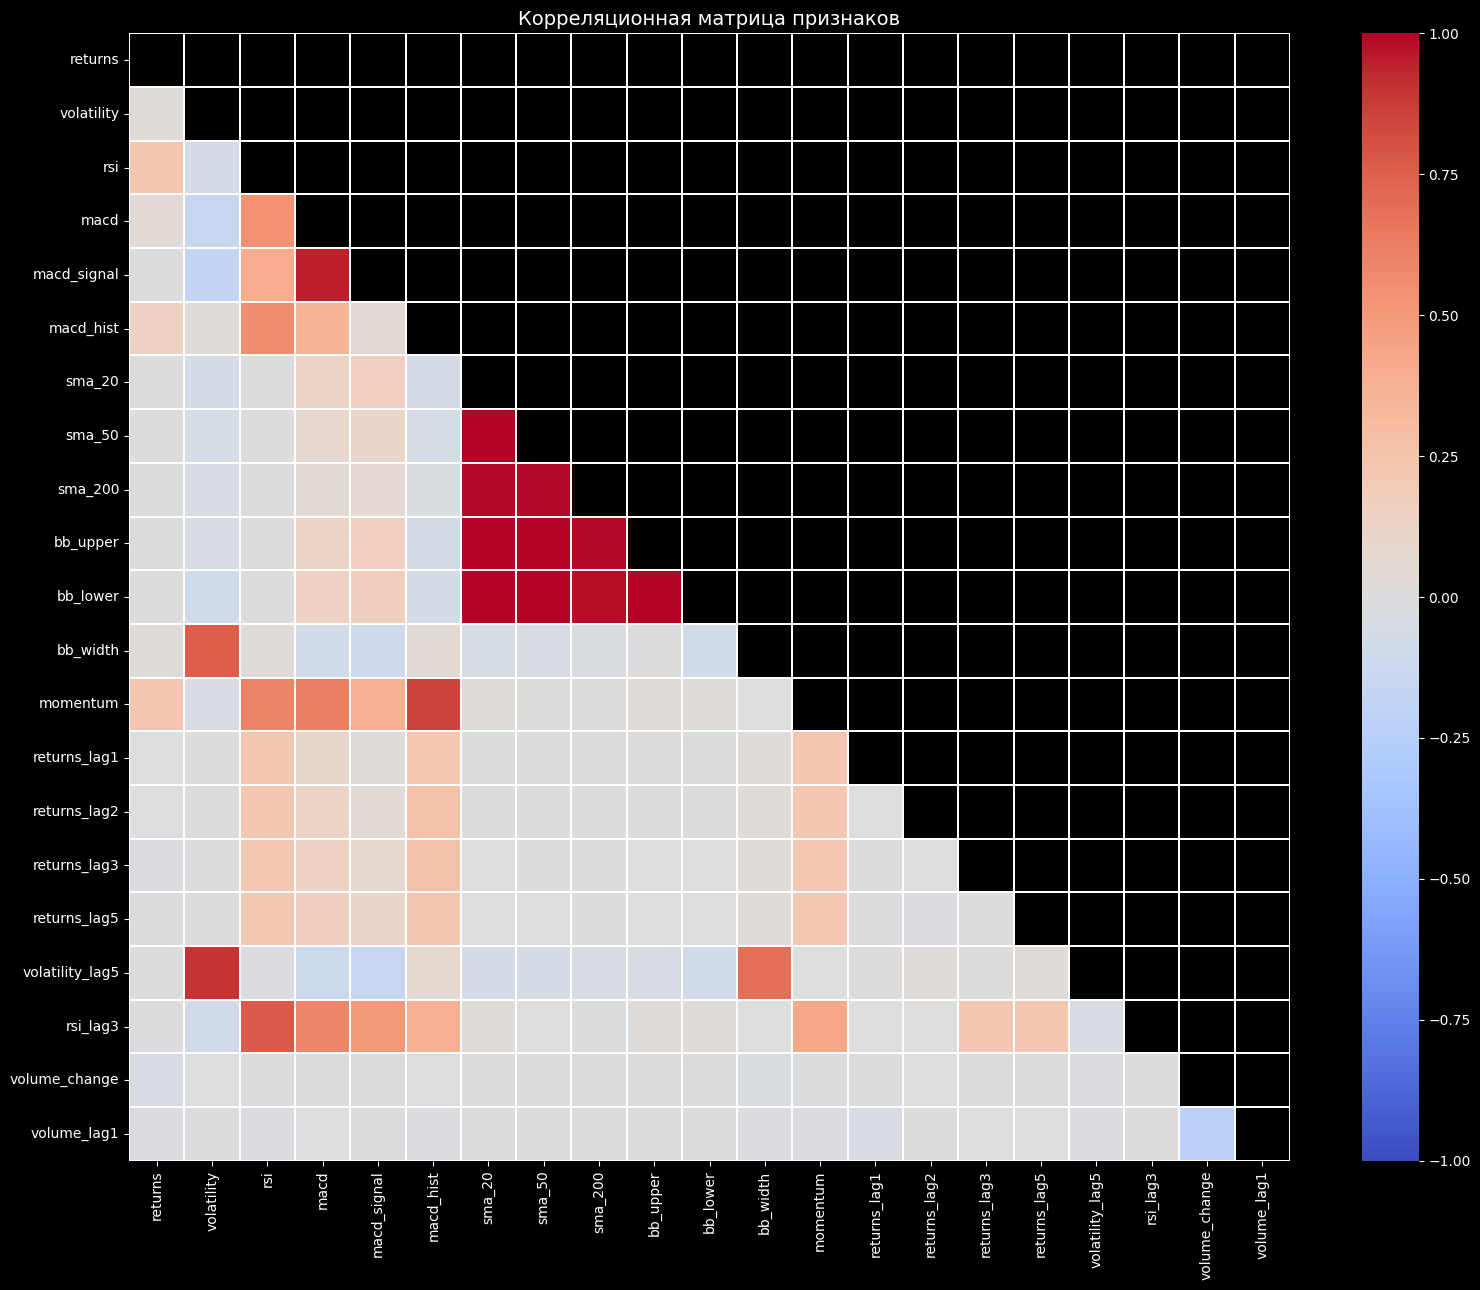

Высокая корреляция (|r| > 0.85): 13 пар
  sma_20               ↔ bb_upper            : 0.999
  sma_20               ↔ bb_lower            : 0.999
  sma_20               ↔ sma_50              : 0.998
  sma_50               ↔ bb_upper            : 0.997
  sma_50               ↔ bb_lower            : 0.996
  bb_upper             ↔ bb_lower            : 0.995
  sma_50               ↔ sma_200             : 0.990
  sma_200              ↔ bb_upper            : 0.985
  sma_20               ↔ sma_200             : 0.985
  sma_200              ↔ bb_lower            : 0.982
  macd                 ↔ macd_signal         : 0.952
  volatility           ↔ volatility_lag5     : 0.899
  macd_hist            ↔ momentum            : 0.857


In [8]:
corr = combined[all_features].dropna().corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=False, cmap='coolwarm',
    center=0, vmin=-1, vmax=1, linewidths=0.2, ax=ax,
)
ax.set_title('Корреляционная матрица признаков', fontsize=14)
plt.tight_layout()
plt.show()

high_corr = [
    (c1, c2, corr.loc[c1, c2])
    for i, c1 in enumerate(corr.columns)
    for c2 in corr.columns[i + 1:]
    if abs(corr.loc[c1, c2]) > 0.85
]
print(f'Высокая корреляция (|r| > 0.85): {len(high_corr)} пар')
for c1, c2, r in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True)[:15]:
    print(f'  {c1:20s} ↔ {c2:20s}: {r:.3f}')

## 7. Целевая переменная

Up: 28580  Down: 26640  →  Positive rate: 51.8%


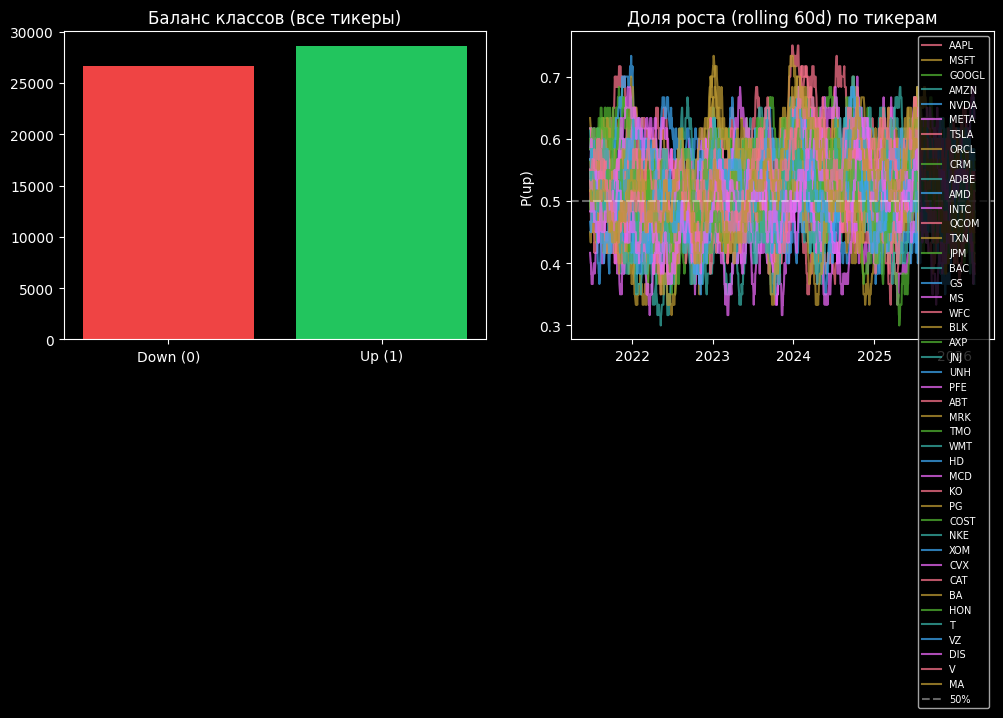

In [9]:
def make_target(df: pd.DataFrame, horizon: int = 1) -> pd.DataFrame:
    df = df.copy().sort_values('date')
    df['target'] = (df['returns'].shift(-horizon) > 0).astype(int)
    return df


combined_t = make_target(combined, horizon=1)
counts = combined_t['target'].value_counts()
pos_rate = counts.get(1, 0) / len(combined_t) * 100
print(f'Up: {counts.get(1, 0)}  Down: {counts.get(0, 0)}  →  Positive rate: {pos_rate:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['Down (0)', 'Up (1)'], [counts.get(0, 0), counts.get(1, 0)],
            color=['#ef4444', '#22c55e'])
axes[0].set_title('Баланс классов (все тикеры)')

for ticker, df in feature_frames.items():
    df_t = make_target(df).sort_values('date')
    roll = df_t['target'].rolling(60).mean()
    axes[1].plot(pd.to_datetime(df_t['date']), roll, label=ticker, alpha=0.75)

axes[1].axhline(0.5, color='white', linestyle='--', alpha=0.4, label='50%')
axes[1].set_title('Доля роста (rolling 60d) по тикерам')
axes[1].set_ylabel('P(up)')
axes[1].legend(fontsize=7)
plt.tight_layout()
plt.show()

## 8. Динамика returns и RSI

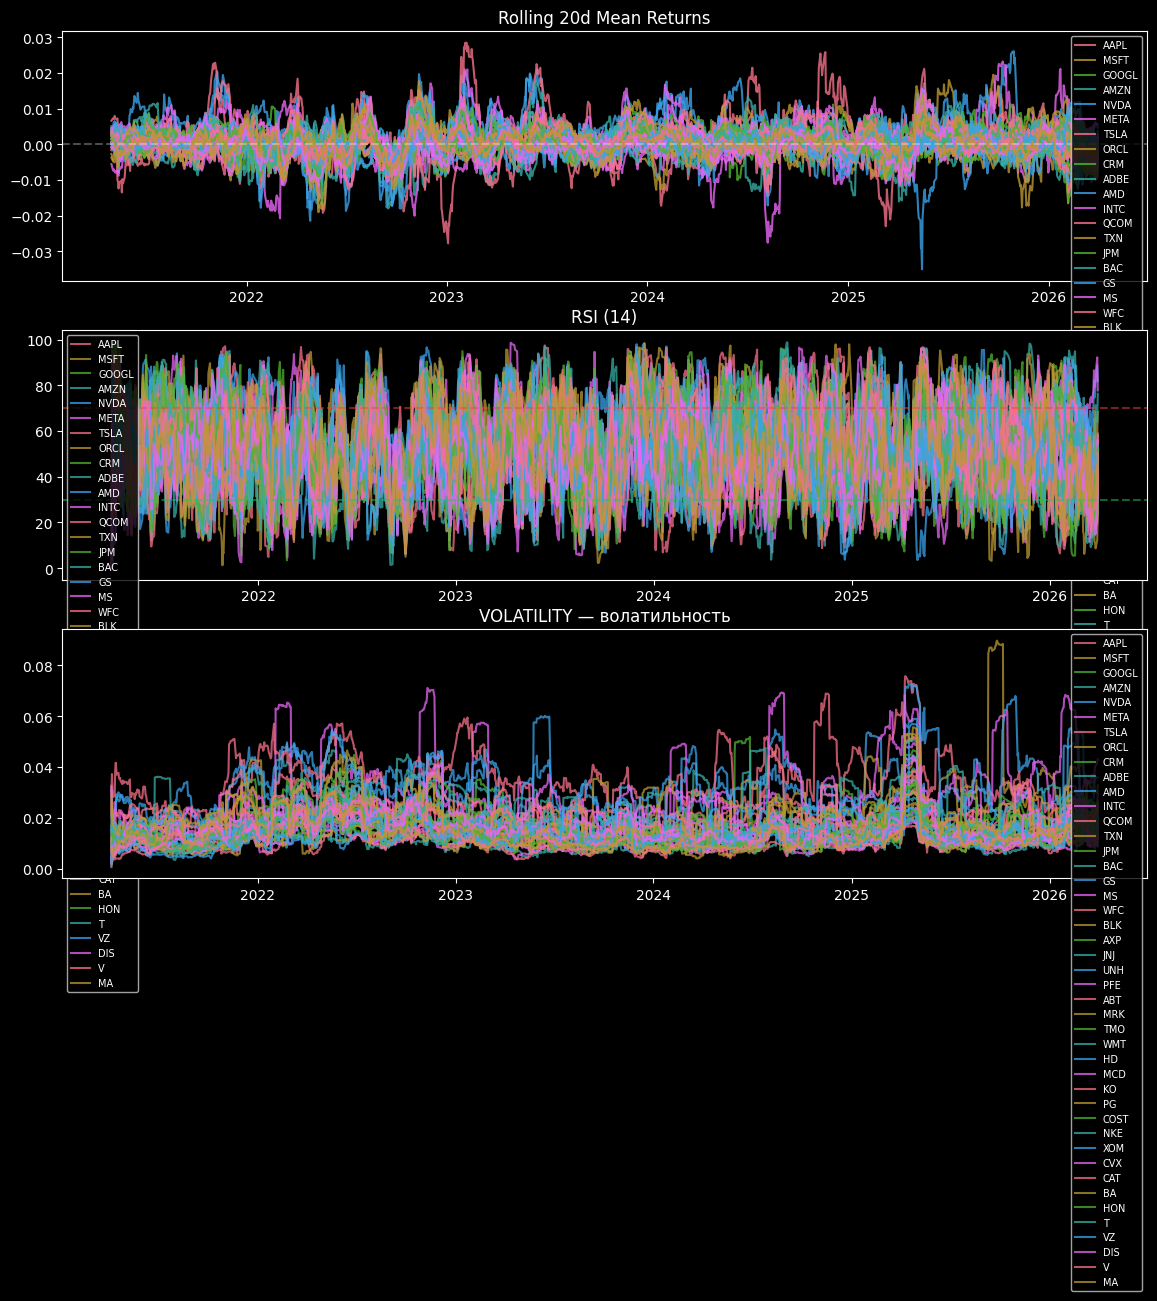

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=False)

for ticker, df in feature_frames.items():
    d = df.sort_values('date')
    axes[0].plot(pd.to_datetime(d['date']), d['returns'].rolling(20).mean(),
                 label=ticker, alpha=0.8)
axes[0].axhline(0, color='white', linestyle='--', alpha=0.3)
axes[0].set_title('Rolling 20d Mean Returns')
axes[0].legend(fontsize=7)

for ticker, df in feature_frames.items():
    d = df.sort_values('date')
    axes[1].plot(pd.to_datetime(d['date']), d['rsi'], label=ticker, alpha=0.75)
axes[1].axhline(70, color='#ef4444', linestyle='--', alpha=0.5)
axes[1].axhline(30, color='#22c55e', linestyle='--', alpha=0.5)
axes[1].set_title('RSI (14)')
axes[1].legend(fontsize=7)

# ATR или volatility — что есть в данных
_vol_col = 'atr' if 'atr' in next(iter(feature_frames.values())).columns else 'volatility'
for ticker, df in feature_frames.items():
    d = df.sort_values('date')
    axes[2].plot(pd.to_datetime(d['date']), d[_vol_col], label=ticker, alpha=0.75)
axes[2].set_title(f'{_vol_col.upper()} — волатильность')
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.show()

## 9. Предиктивная сила признаков (point-biserial correlation с target)

Топ-15 признаков по связи с target:
                      r         p significant
returns        0.220906       0.0        True
rsi             0.06189       0.0        True
momentum       0.061342       0.0        True
macd_hist      0.036237       0.0        True
volume_change -0.032235       0.0        True
macd           0.015357  0.000326        True
bb_width       0.009302  0.029486        True
volume_lag1   -0.008276  0.052772       False
rsi_lag3      -0.005992  0.160867       False
returns_lag5   -0.00494  0.247695       False
volatility     0.004753   0.26607       False
macd_signal    0.004574  0.284502       False
returns_lag1   0.004105   0.33674       False
bb_upper       0.003408  0.425131       False
sma_20         0.003174  0.457652       False


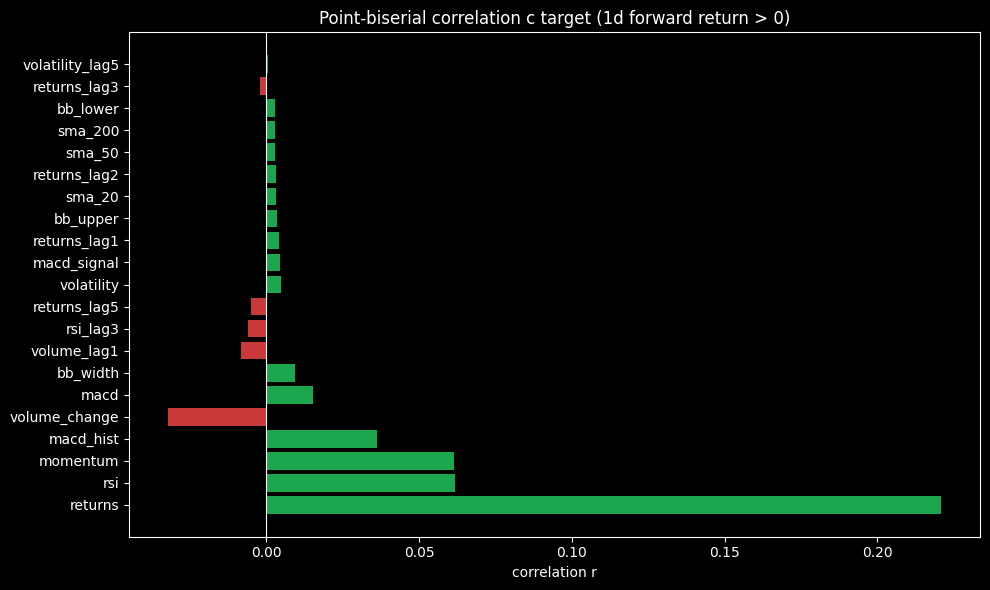

In [11]:
from scipy import stats as scipy_stats

df_clean = combined_t[all_features + ['target']].dropna()

pb_corr = {}
for feat in all_features:
    r, p = scipy_stats.pointbiserialr(df_clean['target'], df_clean[feat])
    pb_corr[feat] = {'r': r, 'p': p, 'significant': p < 0.05}

pb_df = pd.DataFrame(pb_corr).T.sort_values('r', key=abs, ascending=False)
print('Топ-15 признаков по связи с target:')
print(pb_df.head(15).round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#22c55e' if r > 0 else '#ef4444' for r in pb_df['r']]
ax.barh(pb_df.index, pb_df['r'], color=colors, alpha=0.85)
ax.axvline(0, color='white', linewidth=0.8)
ax.set_title('Point-biserial correlation с target (1d forward return > 0)')
ax.set_xlabel('correlation r')
plt.tight_layout()
plt.show()

## 10. Сохранение обработанных данных

## 9b. Макро-фичи (SPY, VIX, QQQ, TLT, GLD)

In [12]:
from app.features.constants import MACRO_FEATURES, SECTOR_FEATURES

MACRO_PANEL_PATH = RAW_DIR / "macro" / "macro_panel.parquet"

def build_macro_features(date_index: pd.DatetimeIndex) -> pd.DataFrame:
    """
    Вычисляет макро-фичи по дате.
    Возвращает DataFrame с индексом по дате — готов к join с ticker-данными.
    """
    if not MACRO_PANEL_PATH.exists():
        print("[WARN] macro_panel.parquet не найден — макро-фичи пропущены")
        return pd.DataFrame(index=date_index)

    macro = pd.read_parquet(MACRO_PANEL_PATH)
    macro.index = pd.to_datetime(macro.index).tz_localize(None)

    # Дневные доходности
    spy_ret  = macro["SPY"].pct_change()
    qqq_ret  = macro["QQQ"].pct_change() if "QQQ" in macro.columns else pd.Series(dtype=float)
    tlt_ret  = macro["TLT"].pct_change() if "TLT" in macro.columns else pd.Series(dtype=float)
    gld_ret  = macro["GLD"].pct_change() if "GLD" in macro.columns else pd.Series(dtype=float)
    vix      = macro["VIX"] if "VIX" in macro.columns else macro.get("_VIX", pd.Series(dtype=float))

    mf = pd.DataFrame(index=macro.index)
    mf["spy_return"]    = spy_ret
    mf["spy_vol_5d"]    = spy_ret.rolling(5).std()
    mf["vix_level"]     = vix
    mf["vix_change"]    = vix.pct_change() if not vix.empty else np.nan
    mf["qqq_return"]    = qqq_ret
    mf["tlt_return"]    = tlt_ret
    mf["gld_return"]    = gld_ret
    mf["spy_qqq_spread"] = spy_ret - qqq_ret if not qqq_ret.empty else np.nan
    mf["vix_spy_ratio"] = vix / (spy_ret.abs() + 1e-6) if not vix.empty else np.nan

    # Выравниваем по нужному индексу дат (forward-fill пропуски выходных)
    mf = mf.reindex(date_index, method="ffill")
    return mf


# Строим и присоединяем к каждому тикеру
macro_added = 0
for ticker, df in feature_frames.items():
    dates = pd.to_datetime(df["date"])
    macro_df = build_macro_features(dates)

    if macro_df.empty:
        break

    for col in MACRO_FEATURES:
        if col in macro_df.columns:
            df[col] = macro_df[col].values
    feature_frames[ticker] = df
    macro_added += 1

print(f"Макро-фичи добавлены к {macro_added} тикерам")
print(f"Новые колонки: {[c for c in MACRO_FEATURES if c in next(iter(feature_frames.values())).columns]}")

Макро-фичи добавлены к 44 тикерам
Новые колонки: ['spy_return', 'spy_vol_5d', 'vix_level', 'vix_change', 'qqq_return', 'tlt_return', 'gld_return', 'spy_qqq_spread', 'vix_spy_ratio']


## 9c. Сектор-фичи (акция vs её сектор)

In [13]:
import ta as ta_lib
from app.features.constants import SECTOR_FEATURES

# Маппинг тикера → сектор ETF
TICKER_SECTOR = {
    # Tech → XLK
    **{t: 'XLK' for t in ['AAPL','MSFT','GOOGL','AMZN','NVDA','META','ORCL','CRM','ADBE','AMD','INTC','QCOM','TXN']},
    # Finance → XLF
    **{t: 'XLF' for t in ['JPM','BAC','GS','MS','WFC','BLK','AXP','V','MA']},
    # Healthcare → XLV
    **{t: 'XLV' for t in ['JNJ','UNH','PFE','ABT','MRK','TMO']},
    # Energy → XLE
    **{t: 'XLE' for t in ['XOM','CVX']},
    # Consumer/Industrial/Telecom → SPY fallback
    **{t: 'SPY' for t in ['WMT','HD','MCD','KO','PG','COST','NKE','DIS','CAT','BA','HON','T','VZ','TSLA']},
}

# Загружаем сектор ETF данные
MACRO_DIR = RAW_DIR / 'macro'
sector_etfs = {}
for etf in ['XLK', 'XLF', 'XLV', 'XLE', 'SPY']:
    path = MACRO_DIR / f'{etf}.parquet'
    if path.exists():
        df_etf = pd.read_parquet(path)
        df_etf.index = pd.to_datetime(df_etf.index).tz_localize(None)
        df_etf.columns = [c[0].lower() if isinstance(c, tuple) else c.lower() for c in df_etf.columns]
        sector_etfs[etf] = df_etf['close']

print(f'Загружено ETF: {list(sector_etfs.keys())}')


def build_sector_features(df: pd.DataFrame, ticker: str) -> pd.DataFrame:
    etf_name = TICKER_SECTOR.get(ticker, 'SPY')
    if etf_name not in sector_etfs:
        etf_name = 'SPY'
    etf_close = sector_etfs[etf_name]

    # Выравниваем по датам тикера
    dates = pd.to_datetime(df['date'])
    etf_aligned = etf_close.reindex(dates.values, method='ffill')

    # Дневной return сектора
    sec_ret1d = etf_aligned.pct_change()
    # 5d trailing return сектора
    sec_ret5d = etf_aligned.pct_change(5)
    # 5d volatility сектора
    sec_vol5d = sec_ret1d.rolling(5).std()
    # RSI сектора (14 дней)
    sec_rsi = ta_lib.momentum.RSIIndicator(close=etf_aligned, window=14).rsi()

    df = df.copy()
    df['ret1d_vs_sector'] = df['returns'].values - sec_ret1d.values
    df['ret5d_vs_sector'] = df['returns'].rolling(5).sum().values - sec_ret5d.values
    df['sector_ret1d']    = sec_ret1d.values
    df['sector_vol5d']    = sec_vol5d.values
    df['sector_rsi']      = sec_rsi.values
    return df


sector_added = 0
for ticker, df in feature_frames.items():
    feature_frames[ticker] = build_sector_features(df, ticker)
    sector_added += 1

print(f'Сектор-фичи добавлены к {sector_added} тикерам')
sample_cols = [c for c in SECTOR_FEATURES if c in next(iter(feature_frames.values())).columns]
print(f'Фичи: {sample_cols}')

Загружено ETF: ['XLK', 'XLF', 'XLV', 'XLE', 'SPY']
Сектор-фичи добавлены к 44 тикерам
Фичи: ['ret1d_vs_sector', 'ret5d_vs_sector', 'sector_ret1d', 'sector_vol5d', 'sector_rsi']


## 9d. Ценовые паттерны (returns_Nd, 52w extremes, volume ratio, OBV, BB%B)

In [14]:
from app.features.constants import PRICE_FEATURES

def build_price_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    close  = df['close'].astype(float)
    volume = df['volume'].astype(float) if 'volume' in df.columns else pd.Series(dtype=float)

    # Multi-horizon returns
    df['returns_3d']  = close.pct_change(3)
    df['returns_10d'] = close.pct_change(10)
    df['returns_20d'] = close.pct_change(20)

    # Distance from 52-week high/low (annualised ~252 trading days)
    roll252_max = close.rolling(252, min_periods=20).max()
    roll252_min = close.rolling(252, min_periods=20).min()
    df['dist_52w_high'] = close / roll252_max - 1   # <= 0
    df['dist_52w_low']  = close / roll252_min - 1   # >= 0

    # Relative volume (vs 20-day average)
    if not volume.empty:
        vol20 = volume.rolling(20, min_periods=1).mean().replace(0, float('nan'))
        df['volume_ratio'] = volume / vol20
    else:
        df['volume_ratio'] = float('nan')

    # OBV 5-day change rate
    if not volume.empty:
        direction = close.diff().apply(lambda x: 1 if x > 0 else (-1 if x < 0 else 0))
        obv = (direction * volume).cumsum()
        obv_ma5 = obv.rolling(5, min_periods=1).mean()
        df['obv_change'] = obv_ma5.pct_change(5)
    else:
        df['obv_change'] = float('nan')

    # Bollinger Band %B: (price - lower) / (upper - lower)
    if 'bb_upper' in df.columns and 'bb_lower' in df.columns:
        band_width = (df['bb_upper'] - df['bb_lower']).replace(0, float('nan'))
        df['bb_pct'] = (close - df['bb_lower']) / band_width
    else:
        mid = close.rolling(20, min_periods=1).mean()
        std = close.rolling(20, min_periods=1).std()
        upper = mid + 2 * std
        lower = mid - 2 * std
        band_width = (upper - lower).replace(0, float('nan'))
        df['bb_pct'] = (close - lower) / band_width

    return df


# Need volume in feature_frames — re-attach from raw data
RAW_DIR_LOCAL = RAW_DIR  # defined earlier in notebook
price_added = 0
for ticker in list(feature_frames.keys()):
    raw_path = RAW_DIR_LOCAL / f'{ticker}_ohlcv.parquet'
    df = feature_frames[ticker].copy()

    if 'volume' not in df.columns and raw_path.exists():
        raw = pd.read_parquet(raw_path)
        raw.columns = [c[0].lower() if isinstance(c, tuple) else c.lower() for c in raw.columns]
        raw['date'] = pd.to_datetime(raw['date']) if 'date' in raw.columns else pd.to_datetime(raw.index)
        raw = raw.reset_index(drop=True) if 'date' in raw.columns else raw.reset_index()
        # align on date
        df = df.merge(raw[['date', 'volume', 'close']], on='date', how='left',
                      suffixes=('', '_raw'))
        if 'volume_raw' in df.columns:
            df = df.drop(columns=['volume_raw'])

    feature_frames[ticker] = build_price_features(df)
    price_added += 1

sample = next(iter(feature_frames.values()))
found = [c for c in PRICE_FEATURES if c in sample.columns]
print(f'Ценовые фичи добавлены к {price_added} тикерам: {found}')


Ценовые фичи добавлены к 44 тикерам: ['returns_3d', 'returns_10d', 'returns_20d', 'dist_52w_high', 'dist_52w_low', 'volume_ratio', 'obv_change', 'bb_pct']


## 9e. Фундаментальные показатели (статические)

In [15]:
from app.features.constants import FUNDAMENTAL_FEATURES

FUND_PATH = RAW_DIR / 'fundamentals.parquet'
if not FUND_PATH.exists():
    raise FileNotFoundError(f'fundamentals.parquet не найден: {FUND_PATH}')

fund_df = pd.read_parquet(FUND_PATH)
fund_df.index.name = 'ticker'
fund_df = fund_df.reset_index()

# Оставляем только нужные колонки
fund_cols = ['ticker'] + [c for c in FUNDAMENTAL_FEATURES if c in fund_df.columns]
fund_df = fund_df[fund_cols]

# Присоединяем к каждому тикеру (статические значения на все даты)
fund_added = 0
for ticker, df in feature_frames.items():
    row = fund_df[fund_df['ticker'] == ticker]
    if row.empty:
        # заполняем NaN — модель обработает через fillna(0)
        for col in FUNDAMENTAL_FEATURES:
            feature_frames[ticker][col] = float('nan')
    else:
        for col in FUNDAMENTAL_FEATURES:
            if col in row.columns:
                feature_frames[ticker][col] = float(row.iloc[0][col])
            else:
                feature_frames[ticker][col] = float('nan')
    fund_added += 1

found = [c for c in FUNDAMENTAL_FEATURES if c in next(iter(feature_frames.values())).columns]
print(f'Фундаментальные фичи добавлены к {fund_added} тикерам: {found}')


Фундаментальные фичи добавлены к 44 тикерам: ['pe_ratio', 'eps', 'revenue_growth', 'roe', 'debt_to_equity']


## 9f. Sentiment-фичи (FinBERT, статические)

In [16]:
from app.features.constants import SENTIMENT_FEATURES

SENT_PATH = RAW_DIR / 'sentiment_by_ticker.parquet'
if not SENT_PATH.exists():
    raise FileNotFoundError(f'sentiment_by_ticker.parquet не найден: {SENT_PATH}. Запустите 03_sentiment_analysis.ipynb')

sent_df = pd.read_parquet(SENT_PATH)
sent_df.index.name = 'ticker'
sent_df = sent_df.reset_index()

sent_added = 0
for ticker, df in feature_frames.items():
    row = sent_df[sent_df['ticker'] == ticker]
    if row.empty:
        for col in SENTIMENT_FEATURES:
            feature_frames[ticker][col] = float('nan')
    else:
        for col in SENTIMENT_FEATURES:
            if col in row.columns:
                feature_frames[ticker][col] = float(row.iloc[0][col])
            else:
                feature_frames[ticker][col] = float('nan')
    sent_added += 1

found = [c for c in SENTIMENT_FEATURES if c in next(iter(feature_frames.values())).columns]
print(f'Sentiment-фичи добавлены к {sent_added} тикерам: {found}')


Sentiment-фичи добавлены к 44 тикерам: ['sentiment_score', 'news_count', 'positive_ratio', 'negative_ratio', 'sentiment_std']


In [17]:
for ticker, df in feature_frames.items():
    out_dir = PROCESSED_DIR / ticker
    out_dir.mkdir(parents=True, exist_ok=True)

    df_clean = df.dropna(subset=TECHNICAL_FEATURES).copy()
    tech_cols = ['date', 'close'] + TECHNICAL_FEATURES + LAG_FEATURES + MACRO_FEATURES + SECTOR_FEATURES + PRICE_FEATURES + FUNDAMENTAL_FEATURES + SENTIMENT_FEATURES
    tech_df = df_clean[[c for c in tech_cols if c in df_clean.columns]]

    out_path = out_dir / 'technical.parquet'
    tech_df.to_parquet(out_path, index=False)
    n_macro = sum(c in df_clean.columns for c in MACRO_FEATURES)
    n_sector = sum(c in df_clean.columns for c in SECTOR_FEATURES)
    n_price  = sum(c in df_clean.columns for c in PRICE_FEATURES)
    print(f'{ticker}: {len(tech_df)} строк, макро={n_macro} сектор={n_sector} price={n_price} → {out_path}')

print('\nГотово.')

AAPL: 1245 строк, макро=9 сектор=5 price=8 → /Users/dvank1mang1/EquiSense/data/processed/AAPL/technical.parquet
MSFT: 1245 строк, макро=9 сектор=5 price=8 → /Users/dvank1mang1/EquiSense/data/processed/MSFT/technical.parquet
GOOGL: 1245 строк, макро=9 сектор=5 price=8 → /Users/dvank1mang1/EquiSense/data/processed/GOOGL/technical.parquet
AMZN: 1245 строк, макро=9 сектор=5 price=8 → /Users/dvank1mang1/EquiSense/data/processed/AMZN/technical.parquet
NVDA: 1245 строк, макро=9 сектор=5 price=8 → /Users/dvank1mang1/EquiSense/data/processed/NVDA/technical.parquet
META: 1238 строк, макро=9 сектор=5 price=8 → /Users/dvank1mang1/EquiSense/data/processed/META/technical.parquet
TSLA: 1245 строк, макро=9 сектор=5 price=8 → /Users/dvank1mang1/EquiSense/data/processed/TSLA/technical.parquet
ORCL: 1244 строк, макро=9 сектор=5 price=8 → /Users/dvank1mang1/EquiSense/data/processed/ORCL/technical.parquet
CRM: 1245 строк, макро=9 сектор=5 price=8 → /Users/dvank1mang1/EquiSense/data/processed/CRM/technical.

JNJ: 1245 строк, макро=9 сектор=5 price=8 → /Users/dvank1mang1/EquiSense/data/processed/JNJ/technical.parquet
UNH: 1245 строк, макро=9 сектор=5 price=8 → /Users/dvank1mang1/EquiSense/data/processed/UNH/technical.parquet
PFE: 1245 строк, макро=9 сектор=5 price=8 → /Users/dvank1mang1/EquiSense/data/processed/PFE/technical.parquet
ABT: 1245 строк, макро=9 сектор=5 price=8 → /Users/dvank1mang1/EquiSense/data/processed/ABT/technical.parquet
MRK: 1245 строк, макро=9 сектор=5 price=8 → /Users/dvank1mang1/EquiSense/data/processed/MRK/technical.parquet
TMO: 1245 строк, макро=9 сектор=5 price=8 → /Users/dvank1mang1/EquiSense/data/processed/TMO/technical.parquet
WMT: 1245 строк, макро=9 сектор=5 price=8 → /Users/dvank1mang1/EquiSense/data/processed/WMT/technical.parquet


HD: 1245 строк, макро=9 сектор=5 price=8 → /Users/dvank1mang1/EquiSense/data/processed/HD/technical.parquet
MCD: 1245 строк, макро=9 сектор=5 price=8 → /Users/dvank1mang1/EquiSense/data/processed/MCD/technical.parquet
KO: 1245 строк, макро=9 сектор=5 price=8 → /Users/dvank1mang1/EquiSense/data/processed/KO/technical.parquet
PG: 1245 строк, макро=9 сектор=5 price=8 → /Users/dvank1mang1/EquiSense/data/processed/PG/technical.parquet
COST: 1245 строк, макро=9 сектор=5 price=8 → /Users/dvank1mang1/EquiSense/data/processed/COST/technical.parquet
NKE: 1245 строк, макро=9 сектор=5 price=8 → /Users/dvank1mang1/EquiSense/data/processed/NKE/technical.parquet
XOM: 1245 строк, макро=9 сектор=5 price=8 → /Users/dvank1mang1/EquiSense/data/processed/XOM/technical.parquet


CVX: 1245 строк, макро=9 сектор=5 price=8 → /Users/dvank1mang1/EquiSense/data/processed/CVX/technical.parquet
CAT: 1245 строк, макро=9 сектор=5 price=8 → /Users/dvank1mang1/EquiSense/data/processed/CAT/technical.parquet


BA: 1245 строк, макро=9 сектор=5 price=8 → /Users/dvank1mang1/EquiSense/data/processed/BA/technical.parquet
HON: 1245 строк, макро=9 сектор=5 price=8 → /Users/dvank1mang1/EquiSense/data/processed/HON/technical.parquet
T: 1245 строк, макро=9 сектор=5 price=8 → /Users/dvank1mang1/EquiSense/data/processed/T/technical.parquet
VZ: 1245 строк, макро=9 сектор=5 price=8 → /Users/dvank1mang1/EquiSense/data/processed/VZ/technical.parquet
DIS: 1245 строк, макро=9 сектор=5 price=8 → /Users/dvank1mang1/EquiSense/data/processed/DIS/technical.parquet
V: 1245 строк, макро=9 сектор=5 price=8 → /Users/dvank1mang1/EquiSense/data/processed/V/technical.parquet
MA: 1245 строк, макро=9 сектор=5 price=8 → /Users/dvank1mang1/EquiSense/data/processed/MA/technical.parquet

Готово.
